In [2]:
import cv2
import pytesseract
import pandas as pd
import matplotlib.pyplot as plt
import requests
from IPython.display import Image
import os
import json

This tutorial is based on: 
* OpenCV for image processing
* Tesseract OCR for extracting text from images
* Pandas for structuring data 

Image from https://en.wikipedia.org/wiki/Electrocardiography

#### Download images

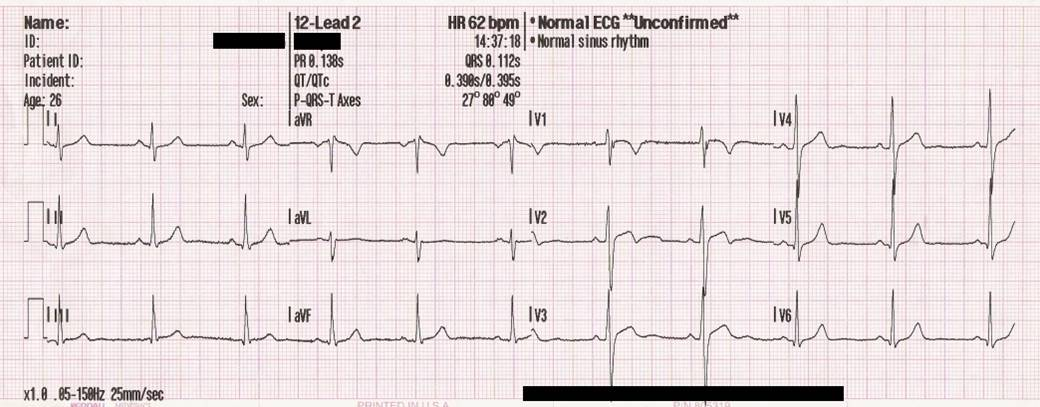

In [225]:
# https://upload.wikimedia.org/wikipedia/commons/a/a2/12_lead_ECG_of_a_26_year_old_male.jpg
 
directory = os.path.join("..", "data", "01")
name = "12_lead_ECG_of_a_26_year_old_male.jpg" 
image_file = os.path.join(directory, name)  
Image(filename=image_file)        

#### Load and preprocess image

In [226]:
# Read image from a file and load it in the form of a NumPy array
image = cv2.imread(image_file)

# Convert the image to grayscale
processed_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) 

# Reduce noise (optional)
# processed_image = cv2.GaussianBlur(processed_image, (1, 1), 0) 

In [227]:
# Function for displaying processed image and extracted text

def display_image_text(image, threshold, text):
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    # Display the image in the first column
    axes[0].imshow(image, cmap='gray')
    axes[0].set_title(f"Threshold Value: {threshold}")
    axes[0].axis('off')  

    # Display the extracted text in the second column
    axes[1].text(0.1, 0.8, text, fontsize=10, wrap=True, verticalalignment='top')
    axes[1].set_title("Extracted Text")
    axes[1].axis('off')  
  
    plt.tight_layout() 
    plt.show()

#### Extracting text with pytesseract

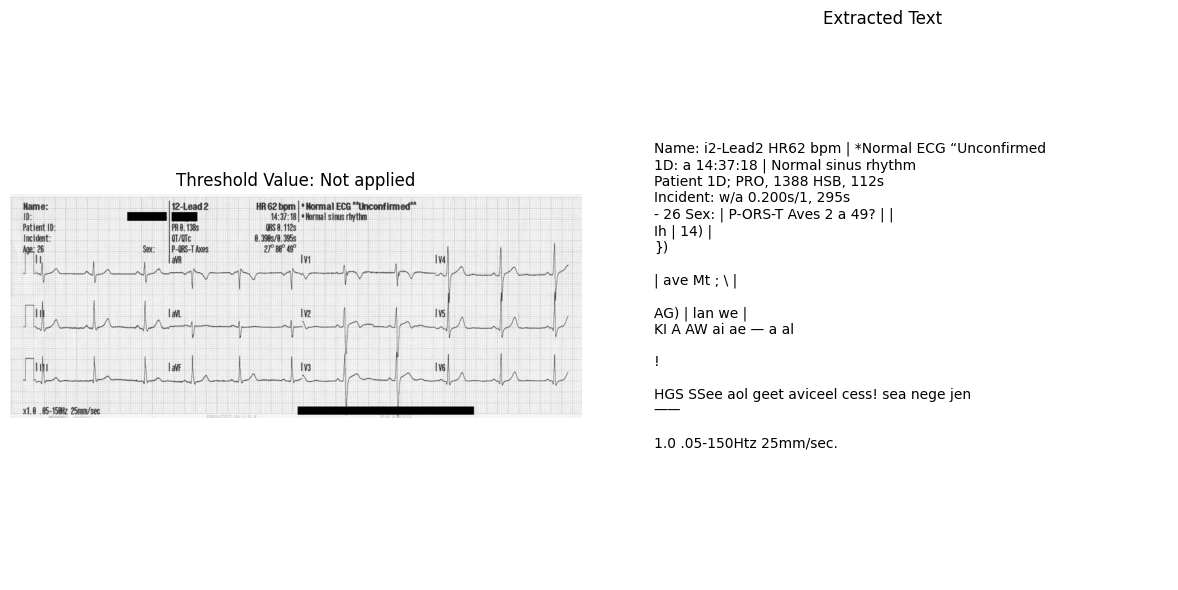

In [247]:
# psm = Page Segmentation Mode, which controls how Tesseract splits the image into text lines, words, and blocks before recognizing characters.
# 3	Fully automatic page layout (default)
# 4	Single column of text of variable size (good for structured print)
# 6	Assume a uniform block of text (no column layout)
# 7	Treat the image as a single text line
# 11 Sparse text, no orientation detection
# 13 Raw line OCR (no layout analysis at all)
custom_config = r'--psm 4' 

extracted_text = pytesseract.image_to_string(processed_image, config=custom_config)

display_image_text(processed_image, "Not applied", extracted_text)

#### Apply thresholding to enhance the text before extracting

##### Var 1: Convert the grayscale image into a binary image, applying a threshold value of 125

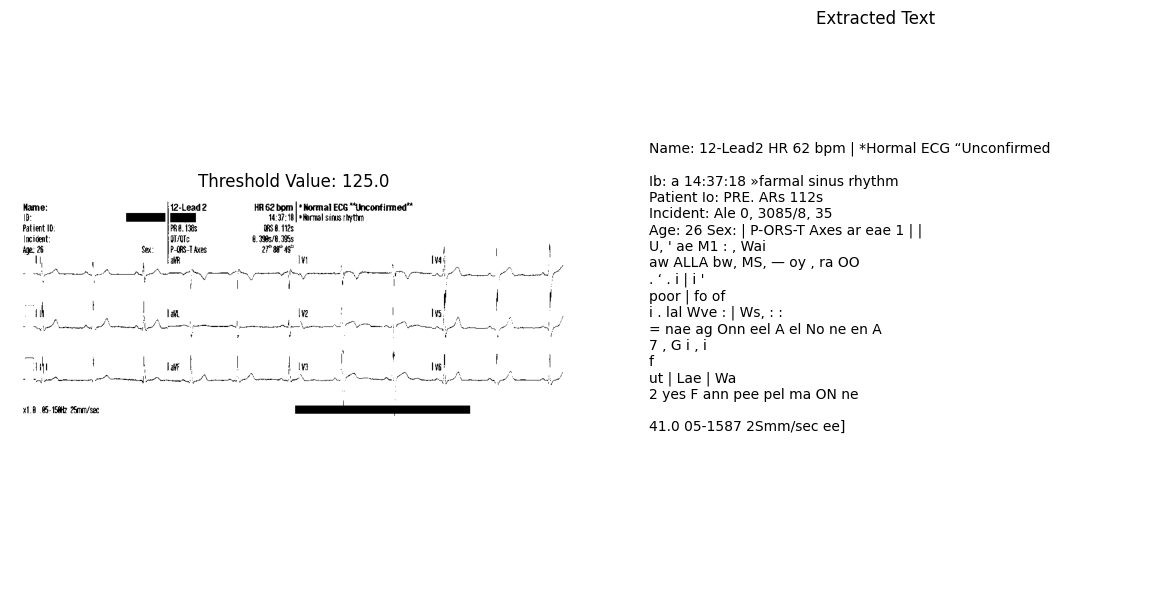

In [252]:
# Any pixel with an intensity greater than or equal to 125 will be set to the maximum value of 255 
threshold_value1, threshold_image1 = cv2.threshold(processed_image, 125, 255, cv2.THRESH_BINARY)  

# psm = Page Segmentation Mode, which controls how Tesseract splits the image into text lines, words, and blocks before recognizing characters.
# 3	Fully automatic page layout (default)
# 4	Single column of text of variable size (good for structured print)
# 6	Assume a uniform block of text (no column layout)
# 7	Treat the image as a single text line
# 11 Sparse text, no orientation detection
# 13 Raw line OCR (no layout analysis at all)
custom_config = r'--psm 4'
 
extracted_text1 = pytesseract.image_to_string(threshold_image1, config=custom_config)

display_image_text(threshold_image1, threshold_value1, extracted_text1)

##### Var 2: Apply Otsu's thresholding method

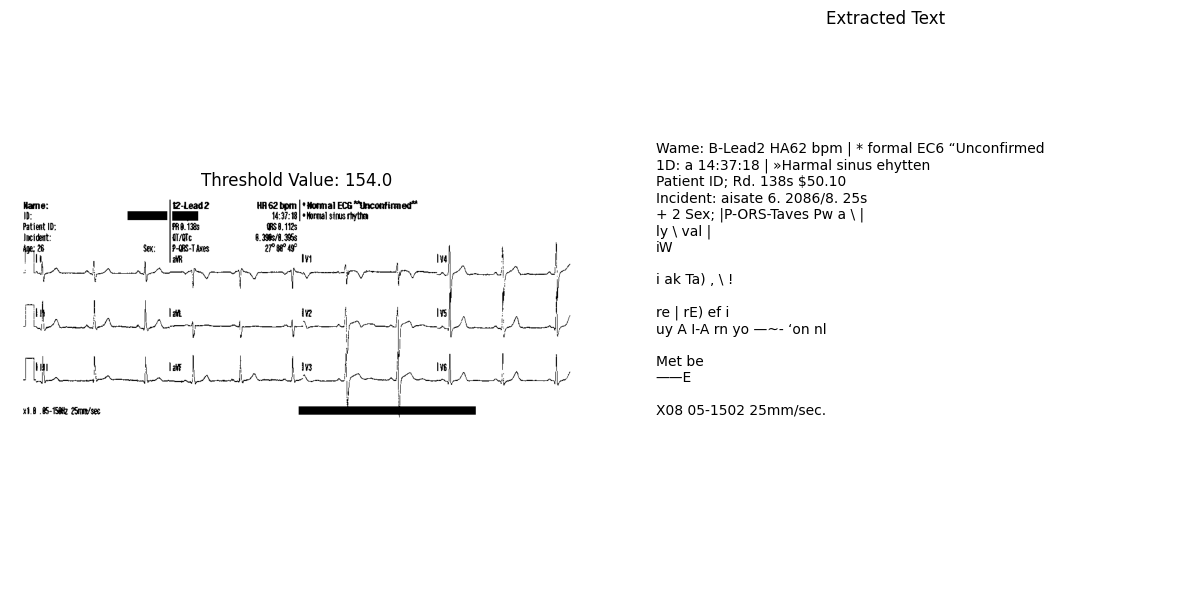

In [251]:
# cv2.THRESH_OTSU does not require a predefined threshold, OpenCV computes the best threshold for separating foreground from background automatically
# threshold_value, threshold_image2 = cv2.threshold(processed_image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
threshold_value2, threshold_image2 = cv2.threshold(processed_image, 0, 255, cv2.THRESH_OTSU) 

# psm = Page Segmentation Mode, which controls how Tesseract splits the image into text lines, words, and blocks before recognizing characters.
# 3	Fully automatic page layout (default)
# 4	Single column of text of variable size (good for structured print)
# 6	Assume a uniform block of text (no column layout)
# 7	Treat the image as a single text line
# 11 Sparse text, no orientation detection
# 13 Raw line OCR (no layout analysis at all)
custom_config = r'--psm 4'
 
extracted_text2 = pytesseract.image_to_string(threshold_image2, config=custom_config)

display_image_text(threshold_image2, threshold_value2, extracted_text2)

##### Var 3: Calculate threshold value for each pixel based on the weighted sum of the neighborhood pixel values

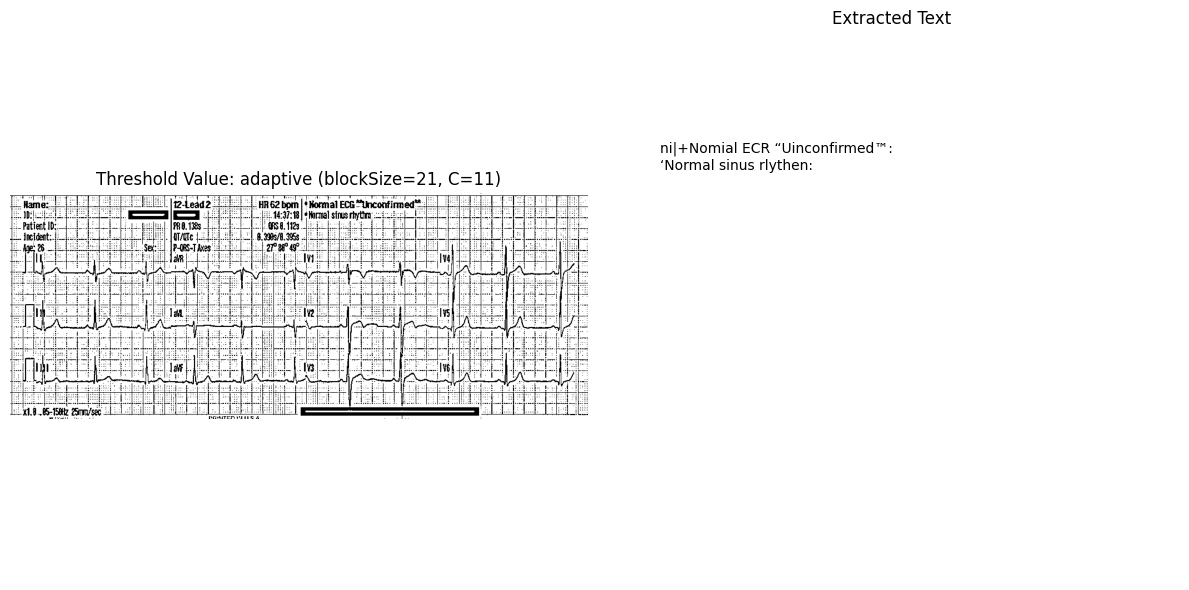

In [262]:
# Calculates different thresholds for different regions of the image, which can be useful for unevenly lit images.
# This method can also be used if the image has varying lighting conditions
blocksize = 21
C = 11
threshold_image3 = cv2.adaptiveThreshold(processed_image, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, blocksize, C)

# ADAPTIVE_THRESH_GAUSSIAN_C calculates the threshold value for each pixel based on the weighted sum of the neighborhood pixel values, 
# where the weights are determined by a Gaussian window. It takes into account local variations in brightness and contrast.

# blocksize is the size of the local neighborhood: a square region ("window") around each pixel used to calculate the threshold value for each pixel.  
# It should be an odd integer (e.g., 3, 5, 7, 11, etc.).   
# Larger window is useful for images with more complex lighting variations, but may blur fine details in the image.

# C is a parameter that fine-tunes the threshold - it is subtracted from the computed threshold to control how aggressive the thresholding is.
# Larger value results in more pixels being set to 0 (black), smaller value makes the threshold more lenient, keeping more pixels white (255).

# An alternative method to use is cv2.ADAPTIVE_THRESH_MEAN_C, which uses the mean of the neighborhood pixel values rather than a weighted sum. 
# The Gaussian method usually produces better results when dealing with images that have non-uniform lighting.

# psm = Page Segmentation Mode, which controls how Tesseract splits the image into text lines, words, and blocks before recognizing characters.
# 3	Fully automatic page layout (default)
# 4	Single column of text of variable size (good for structured print)
# 6	Assume a uniform block of text (no column layout)
# 7	Treat the image as a single text line
# 11 Sparse text, no orientation detection
# 13 Raw line OCR (no layout analysis at all)
custom_config = r'--psm 3'

extracted_text3 = pytesseract.image_to_string(threshold_image3, config=custom_config)

display_image_text(threshold_image3, f"adaptive (blockSize={blocksize}, C={C})", extracted_text3)

#### Extract individual words and bounding boxes using image_to_data

In [264]:
# psm = Page Segmentation Mode, which controls how Tesseract splits the image into text lines, words, and blocks before recognizing characters.
# 3	Fully automatic page layout (default)
# 4	Single column of text of variable size (good for structured print)
# 6	Assume a uniform block of text (no column layout)
# 7	Treat the image as a single text line
# 11 Sparse text, no orientation detection
# 13 Raw line OCR (no layout analysis at all)
custom_config = r'--psm 4' 
 
# Extract text with data (including position, confidence, etc.)
detection_data = pytesseract.image_to_data(processed_image, output_type=pytesseract.Output.DICT, config=custom_config)

# Pretty-print detection data
df = pd.DataFrame(detection_data) 
detected_words = df[df['text'].notnull() & (df['text'].str.len() > 1)]
detected_words

,level,page_num,block_num,par_num,line_num,word_num,left,top,width,height,conf,text
8,5,1,2,1,1,1,21,6,48,33,78,Name:
9,5,1,2,1,1,2,291,6,70,33,61,i2-Lead2
10,5,1,2,1,1,3,444,6,39,33,90,HR62
11,5,1,2,1,1,4,490,6,23,33,90,bpm
13,5,1,2,1,1,6,530,13,208,16,68,*Normal
14,5,1,2,1,1,7,598,6,22,33,94,ECG
15,5,1,2,1,1,8,625,13,113,16,18,“Unconfirmed
17,5,1,2,1,2,1,22,25,17,33,80,1D:
19,5,1,2,1,2,3,475,34,45,14,78,14:37:18
21,5,1,2,1,2,5,530,34,44,14,36,Normal


#### Visualize bounding boxes of extracted words

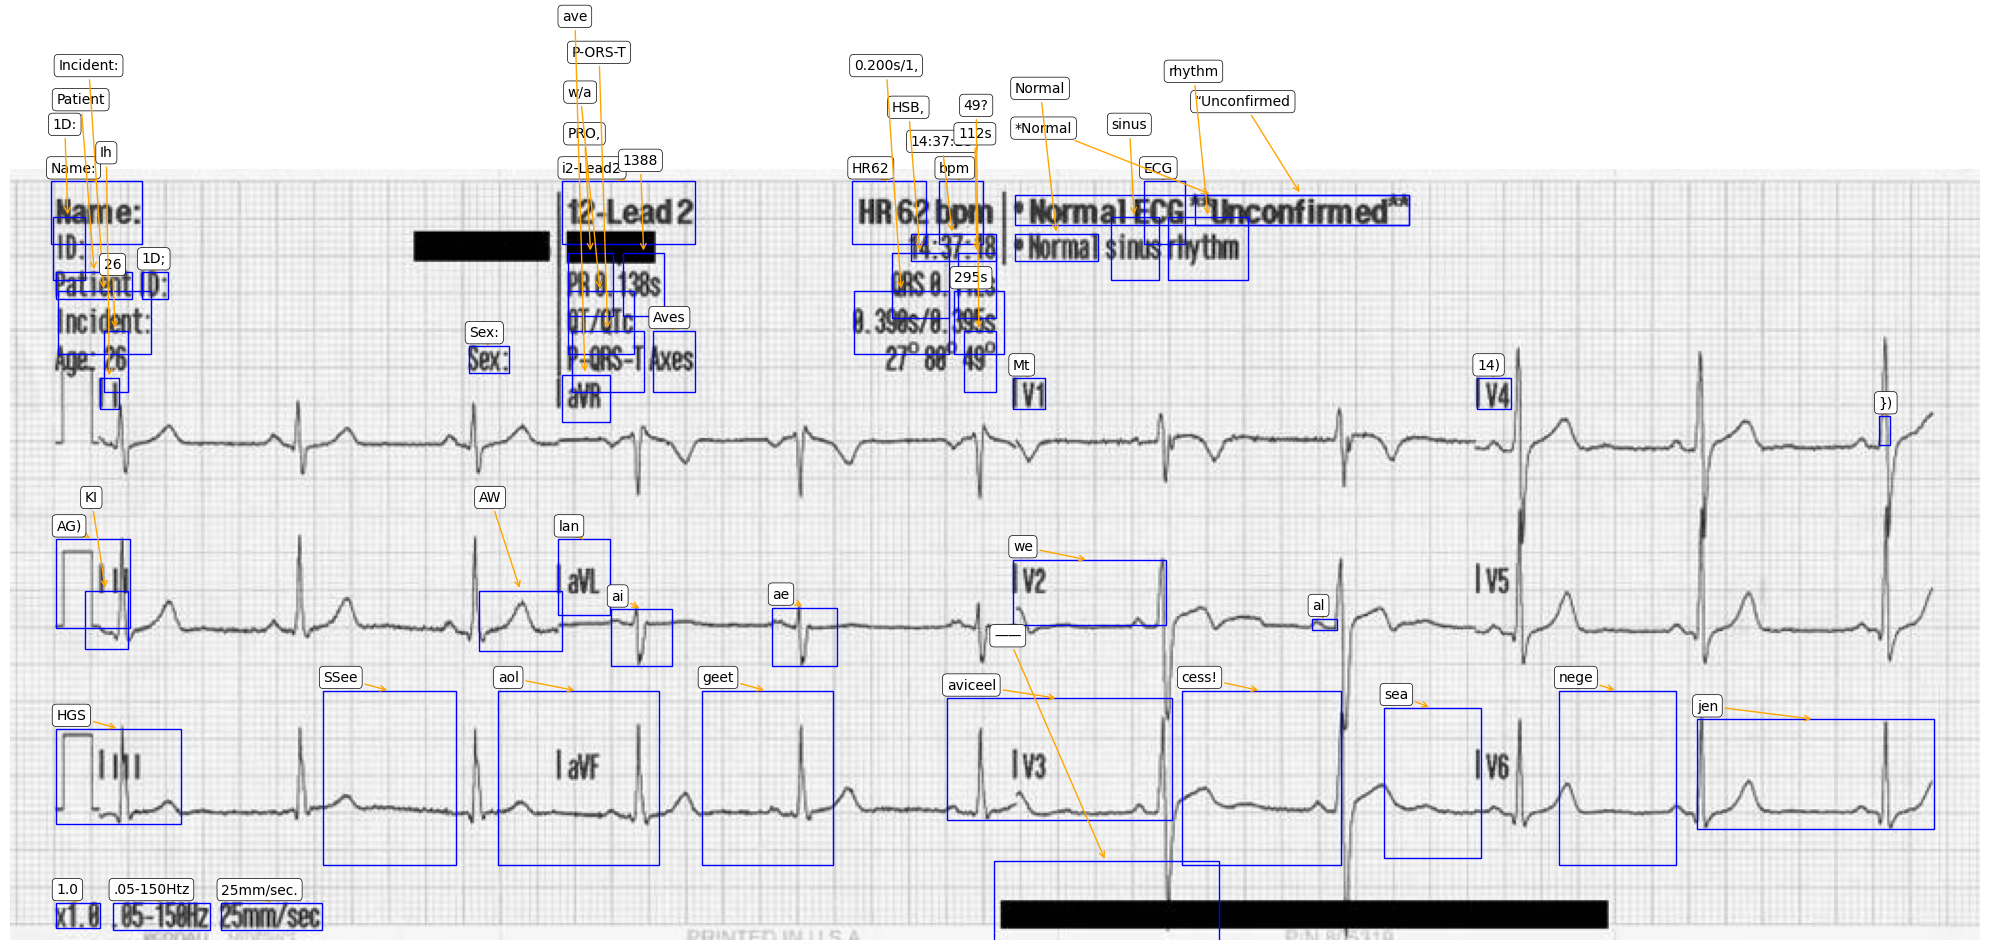

In [265]:
bb_image = cv2.cvtColor(processed_image, cv2.COLOR_GRAY2BGR)

plt.figure(figsize=(20, 30))
plt.imshow(bb_image)
plt.axis('off')

# Settings
text_offset_y = 5
min_text_spacing = 2
font_height = 12

# Bbox positions to prevent overlapping annotations
all_bboxes = [(row.left, row.top, row.width, row.height) for row in detected_words.itertuples()]
placed_text_boxes = []

# Sort detected words by vertical position 
for row in detected_words.sort_values(by='top').itertuples():
    x, y, w, h = row.left, row.top, row.width, row.height
    text = row.text

    # Draw bbox
    plt.gca().add_patch(
        plt.Rectangle((x, y), w, h, edgecolor='blue', facecolor='none', linewidth=1)
    )

    # Initial position of text above the bbox
    init_y = y - text_offset_y

    # Avoid overlapping with any bbox or other text
    while any(
        (bx <= x <= bx + bw or bx <= x + w <= bx + bw) and  # horizontal overlap
        (by <= init_y <= by + bh)
        for bx, by, bw, bh in all_bboxes
    ) or any(
        abs(init_y - other_y) < font_height and abs(x - other_x) < w
        for other_x, other_y in placed_text_boxes
    ):
        init_y -= (font_height + min_text_spacing)

    placed_text_boxes.append((x, init_y))

    # Add annotation with arrow
    plt.annotate(
        text,
        xy=(x + w // 2, y),      # Arrow tip (top center of bbox)
        xytext=(x, init_y),      # Text position above
        arrowprops=dict(arrowstyle="->", color='orange'),
        fontsize=10,
        color='black',
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=0.5)
    )

plt.tight_layout()
plt.show()

#### Save extracted information in structured format

In [266]:
# Organize the extracted information into a structured format like CSV or JSON 

# Save the result as JSON file
df.to_json(os.path.join(directory, 'output.json'), orient='records', lines=True) 
print(df.to_json(orient='records', lines=True))

# Save the result as CSV file
df.to_csv(os.path.join(directory, 'output.csv'), index=False) 

{"level":1,"page_num":1,"block_num":0,"par_num":0,"line_num":0,"word_num":0,"left":0,"top":0,"width":1040,"height":407,"conf":-1,"text":""}
{"level":2,"page_num":1,"block_num":1,"par_num":0,"line_num":0,"word_num":0,"left":524,"top":12,"width":2,"height":39,"conf":-1,"text":""}
{"level":3,"page_num":1,"block_num":1,"par_num":1,"line_num":0,"word_num":0,"left":524,"top":12,"width":2,"height":39,"conf":-1,"text":""}
{"level":4,"page_num":1,"block_num":1,"par_num":1,"line_num":1,"word_num":0,"left":524,"top":12,"width":2,"height":39,"conf":-1,"text":""}
{"level":5,"page_num":1,"block_num":1,"par_num":1,"line_num":1,"word_num":1,"left":524,"top":12,"width":2,"height":39,"conf":95,"text":" "}
{"level":2,"page_num":1,"block_num":2,"par_num":0,"line_num":0,"word_num":0,"left":21,"top":6,"width":971,"height":139,"conf":-1,"text":""}
{"level":3,"page_num":1,"block_num":2,"par_num":1,"line_num":0,"word_num":0,"left":21,"top":6,"width":971,"height":139,"conf":-1,"text":""}
{"level":4,"page_num":1